In [ ]:
# Cell 1 — Step 1. Prepare the Germany security sample
from pathlib import Path
import sqlite3
import math
import os

import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# Project discovery: no hard-coded machine-specific paths.
# -------------------------------------------------------------------
def find_project_root(filename="comp_global_daily.dta"):
    candidates = [Path.cwd().resolve()]
    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parent)

    seen = set()
    expanded = []
    for base in candidates:
        for p in [base, *base.parents]:
            if p not in seen:
                expanded.append(p)
                seen.add(p)

    # First search directly in cwd / parent directories.
    for p in expanded:
        if (p / filename).exists():
            return p

    # Then search one/two levels below the working directory.
    for base in candidates[:1]:
        for match in base.glob(f"*/{filename}"):
            return match.parent
        for match in base.glob(f"*/*/{filename}"):
            return match.parent

    raise FileNotFoundError(
        f"Could not locate {filename}. Place the notebook anywhere inside "
        "the project tree containing the data file."
    )


PROJECT_ROOT = find_project_root()
DATA_FILE = PROJECT_ROOT / "comp_global_daily.dta"
WORK_DIR = PROJECT_ROOT / ".gsy_python_work"
WORK_DIR.mkdir(exist_ok=True)
DB_FILE = WORK_DIR / "germany_replication.sqlite"

CHUNK_SIZE = 200_000
RESET_WORKING_DB = True

if RESET_WORKING_DB and DB_FILE.exists():
    DB_FILE.unlink()

conn = sqlite3.connect(DB_FILE)
conn.execute("PRAGMA journal_mode=WAL;")
conn.execute("PRAGMA synchronous=NORMAL;")
conn.execute("PRAGMA temp_store=FILE;")
conn.execute("PRAGMA cache_size=-200000;")

# -------------------------------------------------------------------
# Reusable helpers for the remaining cells.
# Large security-level intermediate datasets stay disk-backed in
# SQLite instead of being loaded into RAM.
# -------------------------------------------------------------------
def drop_table(table_name):
    conn.execute(f'DROP TABLE IF EXISTS "{table_name}"')
    conn.commit()


def create_index(table_name, columns):
    idx_name = f"idx_{table_name}_{'_'.join(columns)}"
    cols = ", ".join(f'"{c}"' for c in columns)
    conn.execute(f'CREATE INDEX IF NOT EXISTS "{idx_name}" '
                 f'ON "{table_name}" ({cols})')
    conn.commit()


def month_to_period(mdate):
    """
    Convert the Python mdate encoding used in this notebook
    (year * 12 + month, with month = 1,...,12)
    into a pandas monthly PeriodIndex.
    """
    values = pd.to_numeric(
        pd.Series(mdate),
        errors="coerce"
    )

    valid = values.notna()

    result = pd.Series(
        pd.NaT,
        index=values.index,
        dtype="period[M]"
    )

    # Important: subtract 1 before integer division so that
    # December (month=12) is handled correctly.
    month_number = values.loc[valid].astype("int64")

    year = (
        (month_number - 1) // 12
    ).astype("int64")

    month = (
        (month_number - 1) % 12 + 1
    ).astype("int64")

    result.loc[valid] = pd.PeriodIndex(
        pd.to_datetime({
            "year": year,
            "month": month,
            "day": 1
        }),
        freq="M"
    )

    return pd.PeriodIndex(result)


def period_to_mdate(values):
    """
    Convert pandas monthly periods back to the notebook's
    year * 12 + month encoding.
    """
    p = pd.PeriodIndex(values, freq="M")
    return p.year * 12 + p.month


S


# -------------------------------------------------------------------
# Stata keep-list.
# -------------------------------------------------------------------
KEEP_COLS = [
    "fic", "gvkey", "iid", "datadate", "conm", "isin", "sedol", "exchg",
    "secstat", "conml", "ggroup", "gind", "gsector", "gsubind", "stko",
    "ajexdi", "cshoc", "cshtrd", "curcdd", "div", "divd", "prccd",
    "prchd", "prcld", "tpci", "trfd"
]

drop_table("germany_prepared")

# -------------------------------------------------------------------
# Critical memory constraint:
# comp_global_daily.dta is never loaded in full.
# Each chunk is filtered before being persisted.
# SQLite provides the disk-backed replacement for the very large
# intermediate .dta files used by Stata.
# -------------------------------------------------------------------
reader = pd.read_stata(
    DATA_FILE,
    columns=KEEP_COLS,
    convert_dates=True,
    convert_categoricals=False,
    chunksize=CHUNK_SIZE
)

rows_written = 0
chunks_read = 0

for chunk in reader:
    chunks_read += 1

    fic_mask = chunk["fic"].astype("string").str.strip().eq("DEU")
    tpci_mask = chunk["tpci"].astype("string").str.strip().eq("0")
    sector_mask = chunk["gsector"].notna()
    price_mask = pd.to_numeric(chunk["prccd"], errors="coerce").gt(0)

    filtered = chunk.loc[fic_mask & tpci_mask & sector_mask & price_mask,
                         KEEP_COLS].copy()

    if not filtered.empty:
        filtered.to_sql(
            "germany_prepared",
            conn,
            if_exists="append",
            index=False
        )
        rows_written += len(filtered)

create_index(
    "germany_prepared",
    ["gvkey", "iid", "datadate"]
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input chunks processed: {chunks_read:,}")
print(f"Germany common-equity observations retained: {rows_written:,}")

Project root: A:\UHH\Seminar\Exhibits\GSY_Germany_Replication
Input chunks processed: 51
Germany common-equity observations retained: 8,520,923


In [2]:
# Cell 2 — Step 2. Convert DEM to EUR and record currency changes

drop_table("germany_currency_clean")

sql = """
CREATE TABLE germany_currency_clean AS
WITH filtered AS (
    SELECT
        p.*,
        CASE
            WHEN TRIM(CAST(curcdd AS TEXT)) = 'EUR' THEN 1.0
            WHEN TRIM(CAST(curcdd AS TEXT)) = 'DEM' THEN 1.0 / 1.95583
            ELSE NULL
        END AS fx_eur
    FROM germany_prepared AS p
    WHERE TRIM(CAST(curcdd AS TEXT)) IN ('EUR', 'DEM')
),
ordered AS (
    SELECT
        f.*,
        LAG(curcdd) OVER (
            PARTITION BY gvkey, iid
            ORDER BY datadate
        ) AS previous_currency
    FROM filtered AS f
)
SELECT
    *,
    CASE
        WHEN previous_currency IS NOT NULL
             AND previous_currency <> curcdd
        THEN 1
        ELSE 0
    END AS currency_transition
FROM ordered
"""

conn.execute(sql)
conn.commit()

create_index(
    "germany_currency_clean",
    ["gvkey", "iid", "datadate"]
)

transition_count = pd.read_sql_query(
    """
    SELECT COUNT(*) AS n_transitions
    FROM germany_currency_clean
    WHERE currency_transition = 1
    """,
    conn
).iloc[0, 0]

currency_counts = pd.read_sql_query(
    """
    SELECT TRIM(CAST(curcdd AS TEXT)) AS currency, COUNT(*) AS observations
    FROM germany_currency_clean
    GROUP BY 1
    ORDER BY 1
    """,
    conn
)

print("Currency observations:")
display(currency_counts)
print(f"Currency transitions: {int(transition_count):,}")

Currency observations:


,currency,observations
0,DEM,665326
1,EUR,7570857


Currency transitions: 518


In [3]:
# Cell 3 — Step 3. Construct adjusted total-return prices

drop_table("germany_returns_raw")

sql = """
CREATE TABLE germany_returns_raw AS
WITH prices AS (
    SELECT
        c.*,
        CASE
            WHEN prccd > 0
                 AND ajexdi > 0
                 AND fx_eur > 0
                 AND trfd > 0
            THEN (prccd * fx_eur / ajexdi) * trfd
            ELSE NULL
        END AS tr_price_eur
    FROM germany_currency_clean AS c
),
ordered AS (
    SELECT
        p.*,
        LAG(tr_price_eur) OVER (
            PARTITION BY gvkey, iid
            ORDER BY datadate
        ) AS tr_price_lag
    FROM prices AS p
)
SELECT
    *,
    CASE
        WHEN tr_price_lag > 0
             AND tr_price_eur IS NOT NULL
        THEN tr_price_eur / tr_price_lag - 1.0
        ELSE NULL
    END AS ret_daily
FROM ordered
"""

conn.execute(sql)
conn.commit()

create_index(
    "germany_returns_raw",
    ["gvkey", "iid", "datadate"]
)

summary = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS observations,
        SUM(CASE WHEN tr_price_eur IS NOT NULL THEN 1 ELSE 0 END)
            AS valid_total_return_prices,
        SUM(CASE WHEN ret_daily IS NOT NULL THEN 1 ELSE 0 END)
            AS valid_daily_returns
    FROM germany_returns_raw
    """,
    conn
)

display(summary)

KeyboardInterrupt: 

In [ ]:
# Cell 4 — Step 4. Clean obvious daily return errors

drop_table("germany_daily_clean")

source_info = pd.read_sql_query(
    "PRAGMA table_info(germany_returns_raw)",
    conn
)
source_cols = source_info["name"].tolist()

# Stata drops these variables after constructing the cleaned return.
output_cols = [
    c for c in source_cols
    if c not in {"tr_price_lag", "previous_currency",
                 "currency_transition"}
]

select_output = ", ".join(f"l.{c}" for c in output_cols)

sql = f"""
CREATE TABLE germany_daily_clean AS
WITH lagged AS (
    SELECT
        r.*,
        LAG(tr_price_eur, 2) OVER (
            PARTITION BY gvkey, iid
            ORDER BY datadate
        ) AS tr_price_lag2,
        LAG(ret_daily) OVER (
            PARTITION BY gvkey, iid
            ORDER BY datadate
        ) AS previous_return
    FROM germany_returns_raw AS r
),
flags AS (
    SELECT
        *,
        CASE
            WHEN tr_price_lag2 > 0
            THEN tr_price_eur / tr_price_lag2 - 1.0
            ELSE NULL
        END AS ret_2day,
        CASE
            WHEN (
                (ret_daily > 1.0 OR previous_return > 1.0)
                AND tr_price_lag2 > 0
                AND (tr_price_eur / tr_price_lag2 - 1.0) < 0.20
            )
            THEN 1
            ELSE 0
        END AS bad_reversal,
        CASE
            WHEN ret_daily > 2.0 THEN 1
            ELSE 0
        END AS bad_extreme
    FROM lagged
)
SELECT
    {select_output.replace("l.ret_daily", 
        "CASE WHEN l.bad_reversal = 1 OR l.bad_extreme = 1 "
        "THEN NULL ELSE l.ret_daily END AS ret_daily")}
FROM flags AS l
"""

conn.execute(sql)
conn.commit()

create_index(
    "germany_daily_clean",
    ["gvkey", "iid", "datadate"]
)

cleaning_stats = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS observations,
        SUM(CASE WHEN bad_return = 1 THEN 1 ELSE 0 END)
            AS bad_returns
    FROM (
        SELECT
            CASE
                WHEN (
                    (ret_daily > 1.0 OR
                     LAG(ret_daily) OVER (
                        PARTITION BY gvkey, iid ORDER BY datadate
                     ) > 1.0)
                    AND tr_price_lag2 > 0
                    AND (tr_price_eur / tr_price_lag2 - 1.0) < 0.20
                )
                OR ret_daily > 2.0
                THEN 1 ELSE 0
            END AS bad_return
        FROM (
            SELECT
                r.*,
                LAG(tr_price_eur, 2) OVER (
                    PARTITION BY gvkey, iid ORDER BY datadate
                ) AS tr_price_lag2
            FROM germany_returns_raw r
        )
    )
    """,
    conn
)

print("Daily cleaned security table created.")
print("The cleaned return column sets flagged observations to missing.")
display(cleaning_stats)

Daily cleaned security table created.
The cleaned return column sets flagged observations to missing.


,observations,bad_returns
0,8236183,3033


In [ ]:
# Cell 5 — Step 5. Construct monthly security returns

drop_table("germany_monthly_security")

# The reduction from daily to month-end data is performed inside SQLite.
# This avoids materialising millions of daily observations in pandas.
sql = """
CREATE TABLE germany_monthly_security AS
WITH tagged AS (
    SELECT
        d.*,
        (
            CAST(strftime('%Y', datadate) AS INTEGER) * 12
            + CAST(strftime('%m', datadate) AS INTEGER)
        ) AS mdate,
        ROW_NUMBER() OVER (
            PARTITION BY gvkey, iid,
                         CAST(strftime('%Y', datadate) AS INTEGER) * 12
                         + CAST(strftime('%m', datadate) AS INTEGER)
            ORDER BY datadate DESC
        ) AS month_rank
    FROM germany_daily_clean AS d
),
month_ends AS (
    SELECT
        *,
        1 AS month_last
    FROM tagged
    WHERE month_rank = 1
),
lagged AS (
    SELECT
        m.*,
        LAG(tr_price_eur) OVER (
            PARTITION BY gvkey, iid
            ORDER BY mdate
        ) AS tr_price_month_lag,
        LAG(mdate) OVER (
            PARTITION BY gvkey, iid
            ORDER BY mdate
        ) AS previous_mdate
    FROM month_ends AS m
)
SELECT
    * EXCEPT (month_rank),
    CASE
        WHEN tr_price_month_lag > 0
             AND previous_mdate = mdate - 1
        THEN tr_price_eur / tr_price_month_lag - 1.0
        ELSE NULL
    END AS ret_monthly
FROM lagged
"""

# SQLite versions without SELECT * EXCEPT need explicit columns.
# Build an equivalent explicit query dynamically.
daily_info = pd.read_sql_query(
    "PRAGMA table_info(germany_daily_clean)",
    conn
)
daily_cols = daily_info["name"].tolist()

select_cols = ", ".join(
    f"m.{c}" for c in daily_cols
)

sql = f"""
CREATE TABLE germany_monthly_security AS
WITH tagged AS (
    SELECT
        d.*,
        (
            CAST(strftime('%Y', datadate) AS INTEGER) * 12
            + CAST(strftime('%m', datadate) AS INTEGER)
        ) AS mdate,
        ROW_NUMBER() OVER (
            PARTITION BY gvkey, iid,
                         CAST(strftime('%Y', datadate) AS INTEGER) * 12
                         + CAST(strftime('%m', datadate) AS INTEGER)
            ORDER BY datadate DESC
        ) AS month_rank
    FROM germany_daily_clean AS d
),
month_ends AS (
    SELECT
        *,
        1 AS month_last
    FROM tagged
    WHERE month_rank = 1
),
lagged AS (
    SELECT
        m.*,
        LAG(tr_price_eur) OVER (
            PARTITION BY gvkey, iid
            ORDER BY mdate
        ) AS tr_price_month_lag,
        LAG(mdate) OVER (
            PARTITION BY gvkey, iid
            ORDER BY mdate
        ) AS previous_mdate
    FROM month_ends AS m
)
SELECT
    {select_cols},
    m.mdate,
    m.month_last,
    m.tr_price_month_lag,
    CASE
        WHEN m.tr_price_month_lag > 0
             AND m.previous_mdate = m.mdate - 1
        THEN m.tr_price_eur / m.tr_price_month_lag - 1.0
        ELSE NULL
    END AS ret_monthly
FROM lagged AS m
"""

conn.execute(sql)
conn.commit()

create_index(
    "germany_monthly_security",
    ["gvkey", "iid", "mdate"]
)

monthly_security = pd.read_sql_query(
    """
    SELECT *
    FROM germany_monthly_security
    """,
    conn,
    parse_dates=["datadate"]
)

print(f"Month-end security observations: {len(monthly_security):,}")
print(
    f"Unique securities: "
    f"{monthly_security[['gvkey', 'iid']].drop_duplicates().shape[0]:,}"
)

Month-end security observations: 399,627
Unique securities: 2,705


In [ ]:
# Cell 6 — Step 6. Construct value-weighted industry portfolios

df = monthly_security.copy()

df["mktcap_eur"] = np.where(
    (df["prccd"] > 0) &
    (df["fx_eur"] > 0) &
    (df["cshoc"] > 0),
    df["prccd"] * df["fx_eur"] * df["cshoc"],
    np.nan
)

df = df.sort_values(["gvkey", "iid", "mdate"])
df["mktcap_lag"] = (
    df.groupby(["gvkey", "iid"], sort=False)["mktcap_eur"]
      .shift(1)
)

df = df.loc[
    df["gsector"].notna() &
    df["ret_monthly"].notna() &
    df["mktcap_lag"].gt(0)
].copy()

df["industry_mktcap"] = (
    df.groupby(["mdate", "gsector"])["mktcap_lag"]
      .transform("sum")
)

df["industry_weight"] = df["mktcap_lag"] / df["industry_mktcap"]
df["weighted_industry_return"] = (
    df["industry_weight"] * df["ret_monthly"]
)

industry = (
    df.groupby(["gsector", "mdate"])["weighted_industry_return"]
      .sum()
      .rename("industry_return")
      .reset_index()
)

df["market_mktcap"] = df.groupby("mdate")["mktcap_lag"].transform("sum")
df["market_weight"] = df["mktcap_lag"] / df["market_mktcap"]
df["weighted_market_return"] = (
    df["market_weight"] * df["ret_monthly"]
)

market = (
    df.groupby("mdate")["weighted_market_return"]
      .sum()
      .rename("market_return")
      .reset_index()
)

industry_monthly = industry.merge(
    market,
    on="mdate",
    how="left",
    validate="many_to_one"
)

industry_monthly["net_market_return"] = (
    industry_monthly["industry_return"]
    - industry_monthly["market_return"]
)

industry_monthly = (
    industry_monthly[
        ["gsector", "mdate", "industry_return",
         "market_return", "net_market_return"]
    ]
    .drop_duplicates()
    .sort_values(["gsector", "mdate"])
    .reset_index(drop=True)
)

# Stata's encode creates numeric sector identifiers.
sector_categories = pd.Categorical(
    industry_monthly["gsector"]
)
industry_monthly["sector_id"] = (
    sector_categories.codes + 1
)

industry_monthly.to_stata(
    PROJECT_ROOT / "germany_industry_monthly.dta",
    write_index=False,
    version=117
)

# Keep a database copy for later cells.
drop_table("germany_industry_monthly")
industry_monthly.to_sql(
    "germany_industry_monthly",
    conn,
    if_exists="replace",
    index=False
)
create_index(
    "germany_industry_monthly",
    ["gsector", "mdate"]
)

print(f"Industry-month observations: {len(industry_monthly):,}")
print(
    f"Unique GICS sectors: "
    f"{industry_monthly['gsector'].nunique(dropna=True):,}"
)
display(
    industry_monthly[
        ["industry_return", "net_market_return"]
    ].describe(
        percentiles=[0.01, 0.5, 0.99]
    ).T
)

Industry-month observations: 5,755
Unique GICS sectors: 12


,count,mean,std,min,1%,50%,99%,max
industry_return,5755.0,0.007442,0.069349,-0.499567,-0.191225,0.008441,0.184977,1.135808
net_market_return,5755.0,0.000967,0.055652,-0.576381,-0.138672,0.000158,0.155039,1.185765


In [ ]:
# Cell 7 — Step 7. Identify discrete GSY run-up episodes

df = industry_monthly.copy()
df = df.sort_values(["sector_id", "mdate"]).reset_index(drop=True)

df["log_raw"] = np.log1p(df["industry_return"])
df["log_net"] = np.log1p(df["net_market_return"])

df["cumlog_raw"] = (
    df.groupby("sector_id")["log_raw"]
      .cumsum()
)
df["cumlog_net"] = (
    df.groupby("sector_id")["log_net"]
      .cumsum()
)

# Calendar-time rather than row-number lags reproduce Stata's tsset/L# logic.
df = calendar_lookup(
    df,
    ["cumlog_raw", "cumlog_net"],
    offset=-24,
    group_col="sector_id"
)

df["raw_24"] = np.where(
    df["cumlog_raw_offset-24"].notna(),
    np.exp(
        df["cumlog_raw"] - df["cumlog_raw_offset-24"]
    ) - 1.0,
    np.nan
)

df["net_24"] = np.where(
    df["cumlog_net_offset-24"].notna(),
    np.exp(
        df["cumlog_net"] - df["cumlog_net_offset-24"]
    ) - 1.0,
    np.nan
)

df = calendar_lookup(
    df,
    ["cumlog_raw"],
    offset=-60,
    group_col="sector_id"
)

df["raw_60"] = np.where(
    df["cumlog_raw_offset-60"].notna(),
    np.exp(
        df["cumlog_raw"] - df["cumlog_raw_offset-60"]
    ) - 1.0,
    np.nan
)

# Lag the signal by one month to avoid look-ahead.
df = calendar_lookup(
    df,
    ["raw_24", "net_24", "raw_60"],
    offset=-1,
    group_col="sector_id"
)

df["runup_raw24"] = df["raw_24_offset-1"]
df["runup_net24"] = df["net_24_offset-1"]
df["runup_raw60"] = df["raw_60_offset-1"]

thresholds = [50, 75, 100, 125, 150]

for X in thresholds:
    x = X / 100.0

    df[f"qualify{X}"] = (
        df["runup_raw24"].notna()
        & df["runup_net24"].notna()
        & df["runup_raw60"].notna()
        & df["runup_raw24"].ge(x)
        & df["runup_net24"].ge(x)
        & df["runup_raw60"].ge(0.50)
    )

    # A discrete episode cannot be immediately preceded by another
    # qualifying episode during the previous 24 calendar months.
    prior_event = np.zeros(len(df), dtype=bool)

    for lag in range(1, 25):
        shifted = calendar_lookup(
            df[["sector_id", "mdate", f"qualify{X}"]],
            [f"qualify{X}"],
            offset=-lag,
            group_col="sector_id"
        )[f"qualify{X}_offset-{lag}"].fillna(False)

        prior_event |= shifted.to_numpy(dtype=bool)

    df[f"runup{X}"] = (
        df[f"qualify{X}"] & ~prior_event
    )

# Remove temporary lookup columns while retaining all Stata-style outputs.
lookup_cols = [
    c for c in df.columns
    if "offset" in c
]
df = df.drop(columns=lookup_cols)

runup_monthly = df.copy()

runup_monthly.to_stata(
    PROJECT_ROOT / "germany_runup_monthly.dta",
    write_index=False,
    version=117
)

print("Discrete GSY-style run-up episodes:")
display(
    pd.DataFrame({
        "threshold": thresholds,
        "episodes": [
            int(runup_monthly[f"runup{X}"].sum())
            for X in thresholds
        ]
    })
)

Discrete GSY-style run-up episodes:


,threshold,episodes
0,50,14
1,75,8
2,100,6
3,125,6
4,150,3


In [ ]:
# Cell 8 — Step 8. Forward outcomes and maximum drawdowns

df = runup_monthly.copy()

df = (
    df.sort_values(["sector_id", "mdate"])
      .reset_index(drop=True)
)

# -------------------------------------------------------------------
# Create a disk-independent lookup indexed by sector and calendar month.
# This reproduces Stata's tsset + F#. / L#. calendar-time logic.
# -------------------------------------------------------------------
lookup = (
    df.set_index(["sector_id", "mdate"])
      [["cumlog_raw", "cumlog_net"]]
      .sort_index()
)

# -------------------------------------------------------------------
# Helper: retrieve cumulative log return at t + horizon.
#
# For each observation at (sector_id, t), this retrieves the value
# belonging to (sector_id, t + horizon).
# -------------------------------------------------------------------
def future_values(frame, horizon):
    future_index = pd.MultiIndex.from_arrays(
        [
            frame["sector_id"].to_numpy(),
            (frame["mdate"] + horizon).to_numpy()
        ],
        names=["sector_id", "mdate"]
    )

    future = lookup.reindex(future_index)

    return (
        future["cumlog_raw"].to_numpy(),
        future["cumlog_net"].to_numpy()
    )


# -------------------------------------------------------------------
# Determine whether the full 12- and 24-month calendar windows exist.
# -------------------------------------------------------------------
month_sets = (
    df.groupby("sector_id")["mdate"]
      .agg(set)
      .to_dict()
)


def complete_forward_window(row, horizon):
    months = month_sets[row["sector_id"]]
    start = row["mdate"]

    return all(
        (start + j) in months
        for j in range(1, horizon + 1)
    )


df["complete12"] = [
    complete_forward_window(row, 12)
    for _, row in df.iterrows()
]

df["complete24"] = [
    complete_forward_window(row, 24)
    for _, row in df.iterrows()
]


# -------------------------------------------------------------------
# Forward cumulative returns at t+12 and t+24.
# -------------------------------------------------------------------
cumraw12, cumnet12 = future_values(df, 12)
cumraw24, cumnet24 = future_values(df, 24)

df["cumlog_raw_fwd12"] = cumraw12
df["cumlog_net_fwd12"] = cumnet12
df["cumlog_raw_fwd24"] = cumraw24
df["cumlog_net_fwd24"] = cumnet24


# -------------------------------------------------------------------
# Forward 12- and 24-month returns.
# -------------------------------------------------------------------
df["fwd12_raw"] = np.where(
    df["complete12"],
    np.exp(
        df["cumlog_raw_fwd12"] - df["cumlog_raw"]
    ) - 1.0,
    np.nan
)

df["fwd24_raw"] = np.where(
    df["complete24"],
    np.exp(
        df["cumlog_raw_fwd24"] - df["cumlog_raw"]
    ) - 1.0,
    np.nan
)

df["fwd12_net"] = np.where(
    df["complete12"],
    np.exp(
        df["cumlog_net_fwd12"] - df["cumlog_net"]
    ) - 1.0,
    np.nan
)

df["fwd24_net"] = np.where(
    df["complete24"],
    np.exp(
        df["cumlog_net_fwd24"] - df["cumlog_net"]
    ) - 1.0,
    np.nan
)


# -------------------------------------------------------------------
# Maximum drawdown over the following 24 months.
#
# Event month 0 is included as the initial possible peak:
#   wealth_0 = 1
#   peak_0   = 1
#
# For each future month j:
#   wealth_j = exp(cumlog(t+j) - cumlog(t))
#   peak_j   = max(1, wealth_1, ..., wealth_j)
#   dd_j     = wealth_j / peak_j - 1
#
# The maximum drawdown is the minimum dd_j across j = 1,...,24.
# -------------------------------------------------------------------
maxdd_raw = np.where(
    df["complete24"],
    0.0,
    np.nan
)

maxdd_net = np.where(
    df["complete24"],
    0.0,
    np.nan
)

peak_raw = np.where(
    df["complete24"],
    1.0,
    np.nan
)

peak_net = np.where(
    df["complete24"],
    1.0,
    np.nan
)


for j in range(1, 25):

    future_raw, future_net = future_values(df, j)

    wealth_raw = np.exp(
        future_raw - df["cumlog_raw"].to_numpy()
    )

    wealth_net = np.exp(
        future_net - df["cumlog_net"].to_numpy()
    )

    valid_raw = (
        df["complete24"].to_numpy()
        & np.isfinite(wealth_raw)
    )

    valid_net = (
        df["complete24"].to_numpy()
        & np.isfinite(wealth_net)
    )

    # Update running peaks.
    peak_raw[valid_raw] = np.maximum(
        peak_raw[valid_raw],
        wealth_raw[valid_raw]
    )

    peak_net[valid_net] = np.maximum(
        peak_net[valid_net],
        wealth_net[valid_net]
    )

    # Current drawdowns.
    dd_raw = (
        wealth_raw / peak_raw
        - 1.0
    )

    dd_net = (
        wealth_net / peak_net
        - 1.0
    )

    # Keep the worst drawdown encountered so far.
    maxdd_raw[valid_raw] = np.minimum(
        maxdd_raw[valid_raw],
        dd_raw[valid_raw]
    )

    maxdd_net[valid_net] = np.minimum(
        maxdd_net[valid_net],
        dd_net[valid_net]
    )


df["maxdd_raw24"] = maxdd_raw
df["maxdd_net24"] = maxdd_net


# -------------------------------------------------------------------
# Crash indicators.
# A crash occurs when the maximum 24-month drawdown is <= -40%.
# -------------------------------------------------------------------
df["crash_raw40"] = np.where(
    df["complete24"],
    df["maxdd_raw24"] <= -0.40,
    np.nan
)

df["crash_net40"] = np.where(
    df["complete24"],
    df["maxdd_net24"] <= -0.40,
    np.nan
)

df["crash_raw40"] = df["crash_raw40"].astype("boolean")
df["crash_net40"] = df["crash_net40"].astype("boolean")


# -------------------------------------------------------------------
# Remove temporary forward columns.
# -------------------------------------------------------------------
df = df.drop(
    columns=[
        "cumlog_raw_fwd12",
        "cumlog_net_fwd12",
        "cumlog_raw_fwd24",
        "cumlog_net_fwd24"
    ]
)


# -------------------------------------------------------------------
# Final Step 8 output.
# -------------------------------------------------------------------
runup_outcomes = df.copy()

runup_outcomes.to_stata(
    PROJECT_ROOT / "germany_runup_outcomes.dta",
    write_index=False,
    version=117
)


# -------------------------------------------------------------------
# Validation checks against the Stata workflow.
# -------------------------------------------------------------------
n_complete12 = int(
    runup_outcomes["complete12"].sum()
)

n_complete24 = int(
    runup_outcomes["complete24"].sum()
)

n_runup100 = int(
    runup_outcomes["runup100"].sum()
)

n_crash_raw100 = int(
    runup_outcomes.loc[
        runup_outcomes["runup100"],
        "crash_raw40"
    ].sum()
)

n_crash_net100 = int(
    runup_outcomes.loc[
        runup_outcomes["runup100"],
        "crash_net40"
    ].sum()
)

print(f"Industry-month observations: {len(runup_outcomes):,}")
print(f"Complete 12-month windows: {n_complete12:,}")
print(f"Complete 24-month windows: {n_complete24:,}")
print(f"100% run-up episodes: {n_runup100:,}")
print(f"100% raw crashes: {n_crash_raw100:,}")
print(f"100% net-market crashes: {n_crash_net100:,}")

Industry-month observations: 5,755
Complete 12-month windows: 5,599
Complete 24-month windows: 5,443
100% run-up episodes: 6
100% raw crashes: 4
100% net-market crashes: 3


In [ ]:
# Cell 9 — Step 9. Pre-run-up annualized volatility

# -------------------------------------------------------------------
# SQL performs the large daily-security aggregation inside SQLite.
# Only the much smaller daily industry-return panel is materialised
# in pandas.
# -------------------------------------------------------------------
daily_industry_sql = """
WITH base AS (
    SELECT
        d.datadate,
        d.gsector,
        d.gvkey,
        d.iid,
        d.ret_daily,
        CASE
            WHEN d.prccd > 0
                 AND d.fx_eur > 0
                 AND d.cshoc > 0
            THEN d.prccd * d.fx_eur * d.cshoc
            ELSE NULL
        END AS mktcap_eur
    FROM germany_daily_clean AS d
    WHERE d.gsector IS NOT NULL
      AND d.ret_daily IS NOT NULL
),
lagged AS (
    SELECT
        b.*,
        LAG(b.mktcap_eur) OVER (
            PARTITION BY b.gvkey, b.iid
            ORDER BY b.datadate
        ) AS mktcap_lag
    FROM base AS b
),
weighted AS (
    SELECT
        l.*,
        SUM(l.mktcap_lag) OVER (
            PARTITION BY l.datadate, l.gsector
        ) AS sector_mktcap
    FROM lagged AS l
    WHERE l.mktcap_lag > 0
),
industry_daily AS (
    SELECT
        datadate,
        gsector,
        SUM(
            (mktcap_lag / sector_mktcap) * ret_daily
        ) AS industry_daily_ret
    FROM weighted
    WHERE sector_mktcap > 0
    GROUP BY datadate, gsector
)
SELECT
    datadate,
    gsector,
    industry_daily_ret
FROM industry_daily
ORDER BY gsector, datadate
"""

daily_industry = pd.read_sql_query(
    daily_industry_sql,
    conn,
    parse_dates=["datadate"]
)

daily_industry["mdate"] = (
    daily_industry["datadate"].dt.year * 12
    + daily_industry["datadate"].dt.month
)

daily_industry = daily_industry.sort_values(
    ["gsector", "datadate"]
).reset_index(drop=True)

daily_industry["n_daily"] = (
    daily_industry["industry_daily_ret"].notna().astype(int)
)

daily_industry["sum_daily"] = (
    daily_industry["industry_daily_ret"].fillna(0.0)
)

daily_industry["sq_daily"] = (
    daily_industry["industry_daily_ret"].fillna(0.0) ** 2
)

daily_industry["cum_n"] = (
    daily_industry.groupby("gsector")["n_daily"]
    .cumsum()
)

daily_industry["cum_sum"] = (
    daily_industry.groupby("gsector")["sum_daily"]
    .cumsum()
)

daily_industry["cum_sq"] = (
    daily_industry.groupby("gsector")["sq_daily"]
    .cumsum()
)

monthly_end = (
    daily_industry
    .sort_values(["gsector", "datadate"])
    .groupby(["gsector", "mdate"], as_index=False)
    .tail(1)
    .copy()
)

monthly_end = monthly_end[
    [
        "gsector", "mdate", "cum_n",
        "cum_sum", "cum_sq"
    ]
].sort_values(["gsector", "mdate"]).reset_index(drop=True)

# Retrieve cumulative statistics one and thirteen months before t.
monthly_end = calendar_lookup(
    monthly_end,
    ["cum_n", "cum_sum", "cum_sq"],
    offset=-1,
    group_col="gsector"
)

monthly_end = calendar_lookup(
    monthly_end,
    ["cum_n", "cum_sum", "cum_sq"],
    offset=-13,
    group_col="gsector"
)

monthly_end["n12"] = (
    monthly_end["cum_n_offset-1"]
    - monthly_end["cum_n_offset-13"]
)
monthly_end["sum12"] = (
    monthly_end["cum_sum_offset-1"]
    - monthly_end["cum_sum_offset-13"]
)
monthly_end["sq12"] = (
    monthly_end["cum_sq_offset-1"]
    - monthly_end["cum_sq_offset-13"]
)

# Exact Stata condition:
# mdate == L1.mdate + 1 and mdate == L13.mdate + 13.
exact_months = (
    monthly_end["cum_n_offset-1"].notna()
    & monthly_end["cum_n_offset-13"].notna()
)

sample_var = (
    monthly_end["sq12"]
    - monthly_end["sum12"] ** 2 / monthly_end["n12"]
) / (monthly_end["n12"] - 1)

monthly_end["volatility_annual"] = np.where(
    exact_months & monthly_end["n12"].gt(1),
    np.sqrt(sample_var) * np.sqrt(252.0),
    np.nan
)

volatility = monthly_end[
    ["gsector", "mdate", "volatility_annual"]
].copy()

volatility.to_stata(
    PROJECT_ROOT / "germany_industry_volatility.dta",
    write_index=False,
    version=117
)

print(
    f"Annualized volatility observations: "
    f"{volatility['volatility_annual'].notna().sum():,}"
)
display(
    volatility["volatility_annual"].describe(
        percentiles=[0.01, 0.5, 0.99]
    )
)

Annualized volatility observations: 5,589


count    5589.000000
mean        0.225321
std         0.183693
min         0.039718
1%          0.089950
50%         0.193518
99%         0.743403
max         3.383563
Name: volatility_annual, dtype: float64

In [ ]:
# Cell 10 — Step 10. Create the regression-only analysis file

analysis = runup_outcomes.merge(
    volatility,
    on=["gsector", "mdate"],
    how="inner",
    validate="one_to_one"
)

analysis.to_stata(
    PROJECT_ROOT / "germany_gsy_analysis.dta",
    write_index=False,
    version=117
)

print(f"Matched regression-analysis observations: {len(analysis):,}")
print(
    f"Missing volatility observations: "
    f"{analysis['volatility_annual'].isna().sum():,}"
)
print(
    f"Strict 100% episodes with volatility: "
    f"{analysis.loc[analysis['runup100'], 'volatility_annual'].notna().sum():,}"
)

Matched regression-analysis observations: 5,754
Missing volatility observations: 165
Strict 100% episodes with volatility: 6


In [ ]:
# Cell 11 — Step 11. Main threshold exhibit

results = []

for X in [50, 75, 100, 125, 150]:
    subset = runup_outcomes.loc[
        runup_outcomes[f"runup{X}"] == True
    ].copy()

    N = len(subset)

    rawN = int(
        subset["crash_raw40"].eq(True).sum()
    )

    netN = int(
        subset["crash_net40"].eq(True).sum()
    )

    dd = subset["maxdd_raw24"].mean()
    r12 = subset["fwd12_raw"].mean()
    r24 = subset["fwd24_raw"].mean()

    results.append({
        "threshold": X,
        "episodes": N,
        "raw_crashes": rawN,
        "raw_crash_prob": rawN / N if N else np.nan,
        "net_crashes": netN,
        "net_crash_prob": netN / N if N else np.nan,
        "mean_drawdown": dd,
        "mean_fwd12": r12,
        "mean_fwd24": r24
    })

threshold_results = pd.DataFrame(results)

threshold_results["raw_crash_pct"] = (
    100 * threshold_results["raw_crash_prob"]
).round(1)

threshold_results["net_crash_pct"] = (
    100 * threshold_results["net_crash_prob"]
).round(1)

threshold_results["fwd12_raw_pct"] = (
    100 * threshold_results["mean_fwd12"]
).round(1)

threshold_results["fwd24_raw_pct"] = (
    100 * threshold_results["mean_fwd24"]
).round(1)

threshold_results["drawdown_pct"] = (
    100 * threshold_results["mean_drawdown"]
).round(1)

threshold_results = threshold_results[
    [
        "threshold",
        "episodes",
        "fwd12_raw_pct",
        "fwd24_raw_pct",
        "raw_crash_pct",
        "net_crash_pct",
        "drawdown_pct"
    ]
]

threshold_results.columns = [
    "Pick-up threshold (%)",
    "Number of run-ups identified",
    "12M raw return (%)",
    "24M raw return (%)",
    "Raw crashes (%)",
    "Net-market crashes (%)",
    "24M drawdown (%)"
]

output_file = PROJECT_ROOT / "germany_crash_results.xlsx"

threshold_results.to_excel(
    output_file,
    index=False,
    engine="openpyxl"
)

display(threshold_results)
print(f"Saved: {output_file.name}")

,Pick-up threshold (%),Number of run-ups identified,12M raw return (%),24M raw return (%),Raw crashes (%),Net-market crashes (%),24M drawdown (%)
0,50,14,9.3,15.7,42.9,35.7,-39.3
1,75,8,13.6,17.4,62.5,50.0,-40.3
2,100,6,-3.2,13.8,66.7,50.0,-42.2
3,125,6,-5.0,26.1,50.0,50.0,-39.0
4,150,3,10.2,11.1,66.7,66.7,-48.3


Saved: germany_crash_results.xlsx


In [ ]:
# Cell 12 — Step 12. Formal crash-probability test

from scipy.stats import norm

df = runup_outcomes.copy()

N_all = int(df["complete24"].eq(True).sum())
C_all = int(
    df.loc[df["complete24"] == True, "crash_raw40"]
      .eq(True)
      .sum()
)
P_all = C_all / N_all

N_cond = int(df["runup100"].eq(True).sum())
C_cond = int(
    df.loc[df["runup100"] == True, "crash_raw40"]
      .eq(True)
      .sum()
)
P_cond = C_cond / N_cond

N_non = int(
    (
        (df["complete24"] == True)
        & (df["runup100"] == False)
    ).sum()
)

C_non = int(
    df.loc[
        (df["complete24"] == True)
        & (df["runup100"] == False),
        "crash_raw40"
    ].eq(True).sum()
)
P_non = C_non / N_non

# Faithful translation of the Stata pooled-proportion calculations.
P_pool = (
    (C_all + C_cond)
    / (N_all + N_cond)
)

SE = math.sqrt(
    P_pool * (1 - P_pool)
    * (1 / N_all + 1 / N_cond)
)

Z = (P_cond - P_all) / SE
pvalue = 2 * norm.cdf(-abs(Z))

P_pool2 = (
    (C_cond + C_non)
    / (N_cond + N_non)
)

SE2 = math.sqrt(
    P_pool2 * (1 - P_pool2)
    * (1 / N_cond + 1 / N_non)
)

Z2 = (P_cond - P_non) / SE2
pvalue2 = 2 * norm.cdf(-abs(Z2))

test_results = pd.DataFrame([
    {
        "Comparison": "Unconditional",
        "Observations": N_all,
        "Crashes": C_all,
        "Crash probability (%)": round(100 * P_all, 1),
        "Difference (percentage points)": np.nan,
        "z statistic": np.nan,
        "p-value": np.nan
    },
    {
        "Comparison": "100% run-up",
        "Observations": N_cond,
        "Crashes": C_cond,
        "Crash probability (%)": round(100 * P_cond, 1),
        "Difference (percentage points)": round(
            100 * (P_cond - P_all), 1
        ),
        "z statistic": Z,
        "p-value": pvalue
    },
    {
        "Comparison": "Non-100% months",
        "Observations": N_non,
        "Crashes": C_non,
        "Crash probability (%)": round(100 * P_non, 1),
        "Difference (percentage points)": round(
            100 * (P_cond - P_non), 1
        ),
        "z statistic": Z2,
        "p-value": pvalue2
    }
])

test_results.to_excel(
    PROJECT_ROOT / "germany_crash_test.xlsx",
    index=False,
    engine="openpyxl"
)

display(test_results)

,Comparison,Observations,Crashes,Crash probability (%),Difference (percentage points),z statistic,p-value
0,Unconditional,5443,759,13.9,NaN,NaN,NaN
1,100% run-up,6,4,66.7,52.7,3.719486,0.000200
2,Non-100% months,5437,755,13.9,52.8,3.730072,0.000191


In [ ]:
# Cell 13 — Step 13. Footnote-15-style regressions

import statsmodels.api as sm
from scipy.stats import t as student_t

reg_data = analysis.copy()
reg_data["calyear"] = (
    reg_data["mdate"] // 12
)

for X in [50, 75, 100, 125, 150]:
    x = X / 100.0

    reg_data[f"rup_raw{X}"] = np.where(
        reg_data["runup_raw24"].notna(),
        reg_data["runup_raw24"] > x,
        np.nan
    )

    reg_data[f"rup_net{X}"] = np.where(
        reg_data["runup_net24"].notna(),
        reg_data["runup_net24"] > x,
        np.nan
    )

def clustered_ols(y, X, groups, predictors):
    Xmat = sm.add_constant(X.astype(float), has_constant="add")
    model = sm.OLS(
        y.astype(float),
        Xmat,
        missing="drop"
    )
    fitted = model.fit(
        cov_type="cluster",
        cov_kwds={
            "groups": groups.loc[model.data.row_labels],
            "use_correction": True,
            "df_correction": True
        }
    )

    n_clusters = groups.loc[
        model.data.row_labels
    ].nunique()

    df_r = max(n_clusters - 1, 1)

    rows = {}
    for predictor in predictors:
        b = fitted.params[predictor]
        se = fitted.bse[predictor]
        p = 2 * student_t.sf(
            abs(b / se),
            df=df_r
        )
        rows[predictor] = (b, se, p)

    return fitted, rows


reg_results = []

for returntype in ["raw", "net"]:
    for X in [50, 75, 100, 125, 150]:

        predictor = f"rup_{returntype}{X}"

        # No volatility control.
        subset = reg_data.loc[
            reg_data["complete24"] == True,
            ["crash_raw40", predictor, "calyear"]
        ].dropna()

        y = subset["crash_raw40"].astype(float)
        xmat = subset[[predictor]].astype(float)

        fitted, stats = clustered_ols(
            y,
            xmat,
            subset["calyear"],
            [predictor]
        )

        b, se, p = stats[predictor]

        reg_results.append({
            "returntype": returntype,
            "threshold": X,
            "volatility": "No",
            "N": int(fitted.nobs),
            "b_runup": b,
            "se_runup": se,
            "p_runup": p,
            "b_vol": np.nan,
            "se_vol": np.nan,
            "p_vol": np.nan,
            "r2": fitted.rsquared
        })

        # With annualized pre-run-up volatility.
        subset = reg_data.loc[
            reg_data["complete24"] == True,
            [
                "crash_raw40",
                predictor,
                "volatility_annual",
                "calyear"
            ]
        ].dropna()

        y = subset["crash_raw40"].astype(float)
        xmat = subset[
            [predictor, "volatility_annual"]
        ].astype(float)

        fitted, stats = clustered_ols(
            y,
            xmat,
            subset["calyear"],
            [predictor, "volatility_annual"]
        )

        b, se, p = stats[predictor]
        bv, sv, pv = stats["volatility_annual"]

        reg_results.append({
            "returntype": returntype,
            "threshold": X,
            "volatility": "Yes",
            "N": int(fitted.nobs),
            "b_runup": b,
            "se_runup": se,
            "p_runup": p,
            "b_vol": bv,
            "se_vol": sv,
            "p_vol": pv,
            "r2": fitted.rsquared
        })

reg_results = pd.DataFrame(reg_results)

for col in [
    "b_runup", "se_runup", "p_runup",
    "b_vol", "se_vol", "p_vol", "r2"
]:
    reg_results[col] = reg_results[col].round(4)

reg_results = reg_results.rename(columns={
    "returntype": "Return type",
    "threshold": "Threshold (%)",
    "volatility": "Volatility control",
    "N": "Observations",
    "b_runup": "Run-up coefficient",
    "se_runup": "Run-up standard error",
    "p_runup": "Run-up p-value",
    "b_vol": "Volatility coefficient",
    "se_vol": "Volatility standard error",
    "p_vol": "Volatility p-value",
    "r2": "R-squared"
})

reg_results.to_excel(
    PROJECT_ROOT / "germany_footnote15_regressions.xlsx",
    index=False,
    engine="openpyxl"
)

display(reg_results)

,Return type,Threshold (%),Volatility control,Observations,Run-up coefficient,Run-up standard error,Run-up p-value,Volatility coefficient,Volatility standard error,Volatility p-value,R-squared
0,raw,50,No,5131,0.1668,0.0742,0.0308,NaN,NaN,NaN,0.0353
1,raw,50,Yes,5121,0.1643,0.0728,0.0301,0.2755,0.1666,0.1069,0.0602
2,raw,75,No,5131,0.2672,0.1026,0.0133,NaN,NaN,NaN,0.0465
3,raw,75,Yes,5121,0.2548,0.0984,0.0138,0.2544,0.1593,0.1189,0.0682
4,raw,100,No,5131,0.3899,0.1460,0.0113,NaN,NaN,NaN,0.0479
5,raw,100,Yes,5121,0.3655,0.1425,0.0146,0.2450,0.1597,0.1337,0.0678
6,raw,125,No,5131,0.4815,0.1599,0.0047,NaN,NaN,NaN,0.0427
7,raw,125,Yes,5121,0.4517,0.1567,0.0066,0.2509,0.1631,0.1326,0.0634
8,raw,150,No,5131,0.5662,0.1352,0.0002,NaN,NaN,NaN,0.0365
9,raw,150,Yes,5121,0.5324,0.1334,0.0003,0.2576,0.1668,0.1313,0.0581


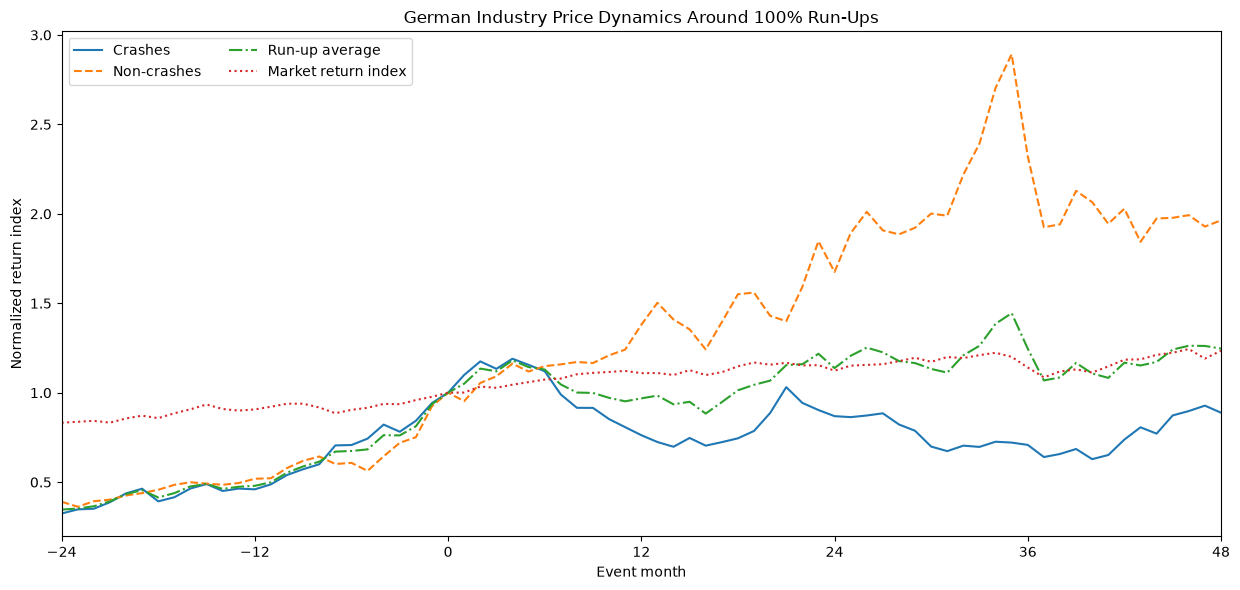

Event-time observations: 73
Observations at event month 0: 1


In [ ]:
# Cell 14 — Step 14. Event-time figure and data

import matplotlib.pyplot as plt

df = runup_outcomes.copy()

episodes = (
    df.loc[df["runup100"] == True,
           ["sector_id", "mdate", "crash_raw40"]]
      .rename(columns={
          "mdate": "event0",
          "crash_raw40": "episode_crash"
      })
      .reset_index(drop=True)
)

episodes["episode_id"] = np.arange(
    1,
    len(episodes) + 1
)

paths = industry_monthly[
    ["sector_id", "mdate",
     "industry_return", "market_return"]
].merge(
    episodes,
    on="sector_id",
    how="inner"
)

paths["event_month"] = (
    paths["mdate"] - paths["event0"]
)

paths = paths.loc[
    paths["event_month"].between(-24, 48)
].copy()

paths = paths.sort_values(
    ["episode_id", "event_month"]
)

paths["log_ind"] = np.log1p(paths["industry_return"])
paths["log_mkt"] = np.log1p(paths["market_return"])

paths["cumlog_ind"] = (
    paths.groupby("episode_id")["log_ind"]
         .cumsum()
)

paths["cumlog_mkt"] = (
    paths.groupby("episode_id")["log_mkt"]
         .cumsum()
)

base_ind = (
    paths.loc[paths["event_month"] == 0]
         .set_index("episode_id")["cumlog_ind"]
)

base_mkt = (
    paths.loc[paths["event_month"] == 0]
         .set_index("episode_id")["cumlog_mkt"]
)

paths["base_ind"] = paths["episode_id"].map(base_ind)
paths["base_mkt"] = paths["episode_id"].map(base_mkt)

paths["ind_index"] = np.exp(
    paths["cumlog_ind"] - paths["base_ind"]
)

paths["mkt_index"] = np.exp(
    paths["cumlog_mkt"] - paths["base_mkt"]
)

paths["crash_index"] = np.where(
    paths["episode_crash"] == True,
    paths["ind_index"],
    np.nan
)

paths["noncrash_index"] = np.where(
    paths["episode_crash"] == False,
    paths["ind_index"],
    np.nan
)

event_paths = (
    paths.groupby("event_month")
         .agg(
             average=("ind_index", "mean"),
             crashes=("crash_index", "mean"),
             noncrashes=("noncrash_index", "mean"),
             market=("mkt_index", "mean")
         )
         .reset_index()
         .sort_values("event_month")
)

event_paths.to_excel(
    PROJECT_ROOT / "germany_event_time_paths.xlsx",
    index=False,
    engine="openpyxl"
)

# -------------------------------------------------------------------
# Reproduce the Stata figure conceptually:
# same event window, line ordering, labels and line styles.
# Matplotlib's default colour cycle is deliberately retained.
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 6.0))

ax.plot(
    event_paths["event_month"],
    event_paths["crashes"],
    linestyle="-",
    label="Crashes"
)

ax.plot(
    event_paths["event_month"],
    event_paths["noncrashes"],
    linestyle="--",
    label="Non-crashes"
)

ax.plot(
    event_paths["event_month"],
    event_paths["average"],
    linestyle="-.",
    label="Run-up average"
)

ax.plot(
    event_paths["event_month"],
    event_paths["market"],
    linestyle=":",
    label="Market return index"
)

ax.set_xlim(-24, 48)
ax.set_xticks([-24, -12, 0, 12, 24, 36, 48])
ax.set_xlabel("Event month")
ax.set_ylabel("Normalized return index")
ax.legend(
    loc="best",
    ncol=2
)
ax.set_title("German Industry Price Dynamics Around 100% Run-Ups")
fig.tight_layout()

fig.savefig(
    PROJECT_ROOT / "germany_event_time_paths.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print(f"Event-time observations: {len(event_paths):,}")
print(
    f"Observations at event month 0: "
    f"{(event_paths['event_month'] == 0).sum():,}"
)

In [6]:
# Cell 15 — Step 15. Table 1-style descriptive exhibit

# -------------------------------------------------------------------
# Raw-only 100% run-up identification.
# This intentionally differs from the stricter GSY specification
# used for the main 100% conditional crash analysis.
# -------------------------------------------------------------------

df = industry_monthly.copy()

df = (
    df.sort_values(["sector_id", "mdate"])
      .reset_index(drop=True)
)

df["log_raw"] = np.log1p(df["industry_return"])

df["cumlog_raw"] = (
    df.groupby("sector_id")["log_raw"]
      .cumsum()
)

# -------------------------------------------------------------------
# Retrieve cumulative log return 24 calendar months earlier.
# -------------------------------------------------------------------

raw_lookup = (
    df.set_index(["sector_id", "mdate"])["cumlog_raw"]
      .sort_index()
)

past24_index = pd.MultiIndex.from_arrays(
    [
        df["sector_id"].to_numpy(),
        (df["mdate"] - 24).to_numpy()
    ],
    names=["sector_id", "mdate"]
)

df["cumlog_raw_24"] = (
    raw_lookup
    .reindex(past24_index)
    .to_numpy()
)

df["raw_24"] = np.where(
    df["cumlog_raw_24"].notna(),
    np.exp(
        df["cumlog_raw"]
        - df["cumlog_raw_24"]
    ) - 1.0,
    np.nan
)

# -------------------------------------------------------------------
# Lag the 24-month signal by one month.
# -------------------------------------------------------------------

raw24_lookup = (
    df.set_index(["sector_id", "mdate"])["raw_24"]
      .sort_index()
)

lag1_index = pd.MultiIndex.from_arrays(
    [
        df["sector_id"].to_numpy(),
        (df["mdate"] - 1).to_numpy()
    ],
    names=["sector_id", "mdate"]
)

df["runup_raw24"] = (
    raw24_lookup
    .reindex(lag1_index)
    .to_numpy()
)

df["qualify100_raw"] = (
    df["runup_raw24"].notna()
    & df["runup_raw24"].ge(1.0)
)

# -------------------------------------------------------------------
# Suppress another qualifying event during the previous 24 months.
# -------------------------------------------------------------------

qualify_lookup = (
    df.set_index(["sector_id", "mdate"])["qualify100_raw"]
      .sort_index()
)

prior_event = np.zeros(
    len(df),
    dtype=bool
)

for lag in range(1, 25):

    lag_index = pd.MultiIndex.from_arrays(
        [
            df["sector_id"].to_numpy(),
            (df["mdate"] - lag).to_numpy()
        ],
        names=["sector_id", "mdate"]
    )

    lag_values = (
        qualify_lookup
        .reindex(lag_index)
        .fillna(False)
        .to_numpy(dtype=bool)
    )

    prior_event |= lag_values

df["table1_runup100"] = (
    df["qualify100_raw"]
    & ~prior_event
)

# -------------------------------------------------------------------
# Keep raw-only Table 1-style episodes.
# -------------------------------------------------------------------

raw_episodes = df.loc[
    df["table1_runup100"],
    ["gsector", "mdate", "runup_raw24"]
].copy()

raw_episodes.to_stata(
    PROJECT_ROOT / "germany_table1_rawepisodes.dta",
    write_index=False,
    version=117
)

# -------------------------------------------------------------------
# Merge with the forward-outcome panel.
# -------------------------------------------------------------------

table1 = runup_outcomes.merge(
    raw_episodes,
    on=["gsector", "mdate"],
    how="inner",
    validate="one_to_one"
)

table1 = table1.loc[
    table1["complete24"] == True
].copy()

# -------------------------------------------------------------------
# Number of firms at each industry-month.
# -------------------------------------------------------------------

firm_counts = (
    monthly_security[
        ["gsector", "mdate", "gvkey", "iid"]
    ]
    .dropna(
        subset=["gsector", "gvkey", "iid"]
    )
    .drop_duplicates()
    .groupby(["gsector", "mdate"])
    .size()
    .rename("number_firms")
    .reset_index()
)

table1 = table1.merge(
    firm_counts,
    on=["gsector", "mdate"],
    how="inner",
    validate="one_to_one"
)

# -------------------------------------------------------------------
# Human-readable variables.
# -------------------------------------------------------------------

table1["industry_name"] = table1["gsector"]

# -------------------------------------------------------------------
# IMPORTANT:
# mdate in this notebook is encoded as:
#
#     year * 12 + month
#
# with month = 1,...,12.
#
# We construct the date through a YYYY-MM string, avoiding the
# pandas datetime assembly problem that produced "19900001".
# -------------------------------------------------------------------

mdate_numeric = pd.to_numeric(
    table1["mdate"],
    errors="coerce"
)

year = (
    (mdate_numeric - 1) // 12
).astype("Int64")

month = (
    (mdate_numeric - 1) % 12 + 1
).astype("Int64")

date_strings = (
    year.astype("string")
    + "-"
    + month.astype("string").str.zfill(2)
    + "-01"
)

table1["runup_date"] = pd.to_datetime(
    date_strings,
    errors="coerce"
)

# -------------------------------------------------------------------
# Reported performance and crash variables.
# -------------------------------------------------------------------

table1["raw12_pct"] = (
    100 * table1["fwd12_raw"]
)

table1["raw24_pct"] = (
    100 * table1["fwd24_raw"]
)

table1["net12_pct"] = (
    100 * table1["fwd12_net"]
)

table1["net24_pct"] = (
    100 * table1["fwd24_net"]
)

table1["drawdown24_pct"] = (
    100 * table1["maxdd_raw24"]
)

table1["crash_pct"] = (
    100 * table1["crash_raw40"].astype(float)
)

# -------------------------------------------------------------------
# Final table structure.
# -------------------------------------------------------------------

table1_output = table1[
    [
        "industry_name",
        "number_firms",
        "runup_date",
        "runup_raw24",
        "raw12_pct",
        "raw24_pct",
        "net12_pct",
        "net24_pct",
        "drawdown24_pct",
        "crash_pct"
    ]
].copy()

table1_output.columns = [
    "Industry name",
    "Number of firms",
    "Price run-up first observed",
    "24-month raw run-up (%)",
    "12-month raw return (%)",
    "24-month raw return (%)",
    "12-month net-of-market return (%)",
    "24-month net-of-market return (%)",
    "24-month drawdown (%)",
    "40% crash indicator (%)"
]

# -------------------------------------------------------------------
# Export final Table 1-style exhibit.
# -------------------------------------------------------------------

output_file = (
    PROJECT_ROOT / "germany_table1_paper_style.xlsx"
)

table1_output.to_excel(
    output_file,
    index=False,
    engine="openpyxl"
)

display(table1_output)

print(
    f"Raw-only 100% Table 1-style episodes: "
    f"{len(table1_output):,}"
)

print(f"Saved: {output_file}")

NameError: name 'industry_monthly' is not defined

In [ ]:
# Cell 16 — Step 16. Save a simple replication-check file

# Faithful translation of the final Stata placeholder:
# the Stata code creates 10 observations, assigns the first check
# label, and sets result equal to _N (= 10). The formal exhibit files
# remain the authoritative empirical outputs.

checks = pd.DataFrame({
    "check": [""] * 10,
    "result": [np.nan] * 10
})

checks.loc[0, "check"] = "50% run-up episodes"
checks.loc[0, "result"] = len(checks)

checks.to_excel(
    PROJECT_ROOT / "germany_replication_checks.xlsx",
    index=False,
    engine="openpyxl"
)

display(checks)

print(
    f"Saved replication-check placeholder: "
    f"{PROJECT_ROOT / 'germany_replication_checks.xlsx'}"
)

conn.close()